# ⚙️ **Predictive Maintenance: Failure Prediction and Anomaly Detection for Industrial Machines**  

---

### 1.0 **Introduction**  
This project explores the application of **Machine Learning** for predictive maintenance in an industrial context. The objectives are twofold:  
- **Predict potential machine failures** using supervised classification models (**XGBoost, Random Forest**)  
- **Detect subtle anomalies** not visible to traditional systems using unsupervised models (**Isolation Forest**)  

---

### 🛠️ **Table of Contents**  
1. 📊 **Data Consultation and Preparation**  
2. 📊 **Exploratory Data Analysis (EDA)**  
3. 🟦 **Supervised Classification (Failure Prediction and Type Identification)**  
4. 📈 **Model Evaluation and Results Interpretation**  
5. 🟢 **Anomaly Detection (Unsupervised Learning)**  
6. 📊 **Insights and Visualization**  
7. 🚀 **Recommendations and Action Plan**


## Installing libraries

In [70]:
%pip install -q pandas
%pip install -q hvplot
%pip install -q matplotlib
%pip install -q seaborn
%pip install -q numpy
%pip install -q imbalanced-learn
%pip install -q xgboost
%pip install -q lightgbm

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Library Importation

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hvplot.pandas

In [72]:
import warnings

# Ignorer les FutureWarnings liés à force_all_finite et sklearn_tags
warnings.filterwarnings("ignore", category=FutureWarning)

# 2.0 Data Consultation

First we load the data set into "PDM_data" and check the type of dataframe

In [73]:
# Read the the csv file then load into "PDM_data"
PDM_data = pd.read_csv('predictive_maintenance.csv')

# Check the object type of the dataframe 
type(PDM_data)

pandas.core.frame.DataFrame

**Then we review the data set information**
- Ensures that the data is loaded in a usable format.
- Prevents errors in subsequent data processing steps.
- Number of missing value per columns

In [74]:
# Reviewing the dataset's metadata to understand its structure and key attributes.
PDM_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


The dataset consists of 10,000 rows and 10 columns, with column data types including int64, object, and float64.

There are no missing values in the original Dataset.

However, one potentially valuable feature for improving the dataset's accuracy could be the temperature difference between Air temperature and Process temperature, as it may help in anomaly detection.

# 3.0 Data Preparation

We introduce two new columns: Temp_Diff (difference between process and air temperatures) to capture potential heat imbalances, and Power (calculated from torque and rotational speed) to represent overall mechanical load. These features provide clearer insights into thermal and mechanical stress, helping improve predictive maintenance.

In [75]:
#Adding a new row for difference of the temperature 
PDM_data['Temp_Diff [K]'] = PDM_data['Process temperature [K]'] - PDM_data['Air temperature [K]']

# Convert rotational speed from rpm to rad/s and compute power in watts
# Power (W) = Torque (Nm) * Angular Speed (rad/s)

PDM_data['Power [W]'] = (
    PDM_data['Torque [Nm]'] *
    (2 * np.pi / 60) *  # conversion factor from rpm to rad/s
    PDM_data['Rotational speed [rpm]']
)

Then, we display the first 15 rows to see what the dataset looks like.

In [76]:
#Display the first 15 data to know how it's look like
PDM_data.head(15)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Temp_Diff [K],Power [W]
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,10.5,6951.590560
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,10.5,6826.722724
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,10.4,7749.387543
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,10.4,5927.504659
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,10.5,5897.816608
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure,10.5,6252.554779
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,No Failure,10.5,6917.703247
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,No Failure,10.5,6428.264056
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure,10.4,4992.639989
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure,10.5,5104.878623


In [77]:
# Compter le nombre de lignes où 'Target' est égal à 1
count_target_1 = PDM_data[PDM_data['Target'] == 1].shape[0]

# Compter le nombre de lignes où 'Target' est égal à 0
count_target_0 = PDM_data[PDM_data['Target'] == 0].shape[0]

# Afficher le tableau comparatif
comparison = {
    'Target = 1': count_target_1,
    'Target = 0': count_target_0
}

# Affichage du résultat
import pandas as pd
comparison_df = pd.DataFrame(comparison, index=[0])
print(comparison_df)

   Target = 1  Target = 0
0         339        9661


Calculate key statistics for each column: mean, standard deviation, min, max, and quartiles.

To improve data readability, we remove non-numeric data only  for the key statistics

In [78]:
PDM_data_drop = PDM_data.drop(columns= ["UDI", "Product ID" , "Type" , "Failure Type", "Target"])
PDM_data_drop.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_Diff [K],Power [W]
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,10.000630,6279.744953
std,2.000259,1.483734,179.284096,9.968934,63.654147,1.001094,1067.418295
min,295.300000,305.700000,1168.000000,3.800000,0.000000,7.600000,1148.440610
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,9.300000,5561.184484
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,9.800000,6271.027344
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,11.000000,7003.002724
max,304.500000,313.800000,2886.000000,76.600000,253.000000,12.100000,10469.923005


- The data appears relatively clean and stable.
- Outliers in Torque and Tool wear could serve as early indicators of potential failures.
- Additionally, the maximum values for Rotational speed, Torque, and Tool wear are significantly higher than their respective third quartiles, suggesting - potential extreme conditions or anomalies requiring further investigation.

We examine the types of failures present in the dataset.

In [79]:
pd.unique(PDM_data["Failure Type"])

array(['No Failure', 'Power Failure', 'Tool Wear Failure',
       'Overstrain Failure', 'Random Failures',
       'Heat Dissipation Failure'], dtype=object)

In [80]:
print(PDM_data['Target'].value_counts())

Target
0    9661
1     339
Name: count, dtype: int64


In [81]:
# Afficher un échantillon de la colonne 'Failure Type'
print(PDM_data['Failure Type'].head(1223))

# Vérifier la présence de valeurs manquantes dans 'Failure Type'
print(PDM_data['Failure Type'].isnull().sum())  # Compte des valeurs NaN

# Filtrer les lignes où 'Failure Type' est exactement 'Random Failures'
random_failure_data = PDM_data[PDM_data['Failure Type'] == 'Random Failures']

# Afficher les lignes filtrées
random_failure_data.head(20)


0            No Failure
1            No Failure
2            No Failure
3            No Failure
4            No Failure
             ...       
1218         No Failure
1219         No Failure
1220         No Failure
1221    Random Failures
1222         No Failure
Name: Failure Type, Length: 1223, dtype: object
0


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Temp_Diff [K],Power [W]
1221,1222,M16081,M,297.0,308.3,1399,46.4,132,0,Random Failures,11.3,6797.736296
1302,1303,L48482,L,298.6,309.8,1505,45.7,144,0,Random Failures,11.2,7202.467677
1748,1749,H31162,H,298.4,307.7,1626,31.1,166,0,Random Failures,9.3,5295.531409
2072,2073,L49252,L,299.6,309.5,1570,35.5,189,0,Random Failures,9.9,5836.555552
2559,2560,L49739,L,299.3,309.0,1447,50.4,140,0,Random Failures,9.7,7637.086077
3065,3066,M17925,M,300.1,309.2,1687,27.7,95,0,Random Failures,9.1,4893.543685
3452,3453,H32866,H,301.6,310.5,1602,32.3,2,0,Random Failures,8.9,5418.681841
5471,5472,L52651,L,302.7,312.3,1346,61.2,170,0,Random Failures,9.6,8626.310772
5489,5490,L52669,L,302.6,312.1,1499,35.0,215,0,Random Failures,9.5,5494.121952
5495,5496,H34909,H,302.9,312.5,1357,55.0,12,0,Random Failures,9.6,7815.758923


In [82]:
ew = PDM_data['Failure Type'] == 'Random Failures'
ew.head(20)
random_failure_data = PDM_data[PDM_data['Failure Type'] == 'Random Failures']
print(random_failure_data['Failure Type'].head(20))

print(PDM_data['Failure Type'].value_counts())
print(PDM_data['Target'].value_counts())
# 📝 Étape 1 : Filtrer les lignes sans "Random Failure"
PDM_data = PDM_data[PDM_data['Failure Type'] != 'Random Failures']

# Vérifier la répartition des labels après filtrage
print(random_failure_data['Failure Type'].head(20))
print(PDM_data['Failure Type'].value_counts())
print(PDM_data['Target'].value_counts())

1221    Random Failures
1302    Random Failures
1748    Random Failures
2072    Random Failures
2559    Random Failures
3065    Random Failures
3452    Random Failures
5471    Random Failures
5489    Random Failures
5495    Random Failures
5509    Random Failures
5553    Random Failures
5639    Random Failures
6091    Random Failures
6913    Random Failures
6960    Random Failures
7488    Random Failures
7868    Random Failures
Name: Failure Type, dtype: object
Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64
Target
0    9661
1     339
Name: count, dtype: int64
1221    Random Failures
1302    Random Failures
1748    Random Failures
2072    Random Failures
2559    Random Failures
3065    Random Failures
3452    Random Failures
5471    Random Failures
5489    Random Failures
5495    Random Failures
5509

# 4.0 Exploratory Data Analysis (EDA)

A histogram of the torque distribution (Torque [Nm]) was generated to detect trends, anomalies, and potential risk zones.

In [83]:

PDM_data.hvplot.hist(y="Torque [Nm]", bins=30, title="Distribution of Torque [Nm]")

:Histogram   [Torque [Nm]]   (Count)

- The "Torque [Nm]" variable follows a slightly right-skewed normal distribution.
- The central value around 40 Nm represents typical operating conditions.
- The extremes, below 20 Nm and above 60 Nm, require further analysis to identify potential anomalies or specific cases.
- The moderate to high variability in torque suggests a machine operating under diverse dynamic conditions.
- Extreme values might indicate exceptional behavior or potential failures.

A histogram of the temperature difference distribution (Temp_Diff) is generated to detect trends, anomalies, and potential risk zones related to temperature variations, which can impact the overall performance and failure rates of the machines.

In [84]:
PDM_data.hvplot.hist(y="Temp_Diff [K]", bins=30, title="Distribution of the Temperature Difference")

:Histogram   [Temp_Diff [K]]   (Count)

The scatter plot of "Speed vs Torque" is generated to visualize the relationship between rotational speed and torque, helping to identify patterns.

In [85]:
PDM_data.hvplot.scatter(x='Rotational speed [rpm]', y='Torque [Nm]', title="Speed vs Torque")

:Scatter   [Rotational speed [rpm]]   (Torque [Nm])

- There is a clear inverse relationship between rotational speed and torque. **This means that the values are consistent.**
- At low speed and high torque, it likely represents a startup phase or a period of high mechanical load.
- At high speed and low torque, the system seems to operate steadily in a stable regime.
- Increased variability at low speeds indicates a less stable or more dynamic operating range.
- Potential anomalies are present, with some outlier points requiring further analysis to identify underlying causes.

The pair plot is suggested to visualize the relationships between all numerical variables in the dataset, detect correlations, identify complex patterns, and spot anomalies

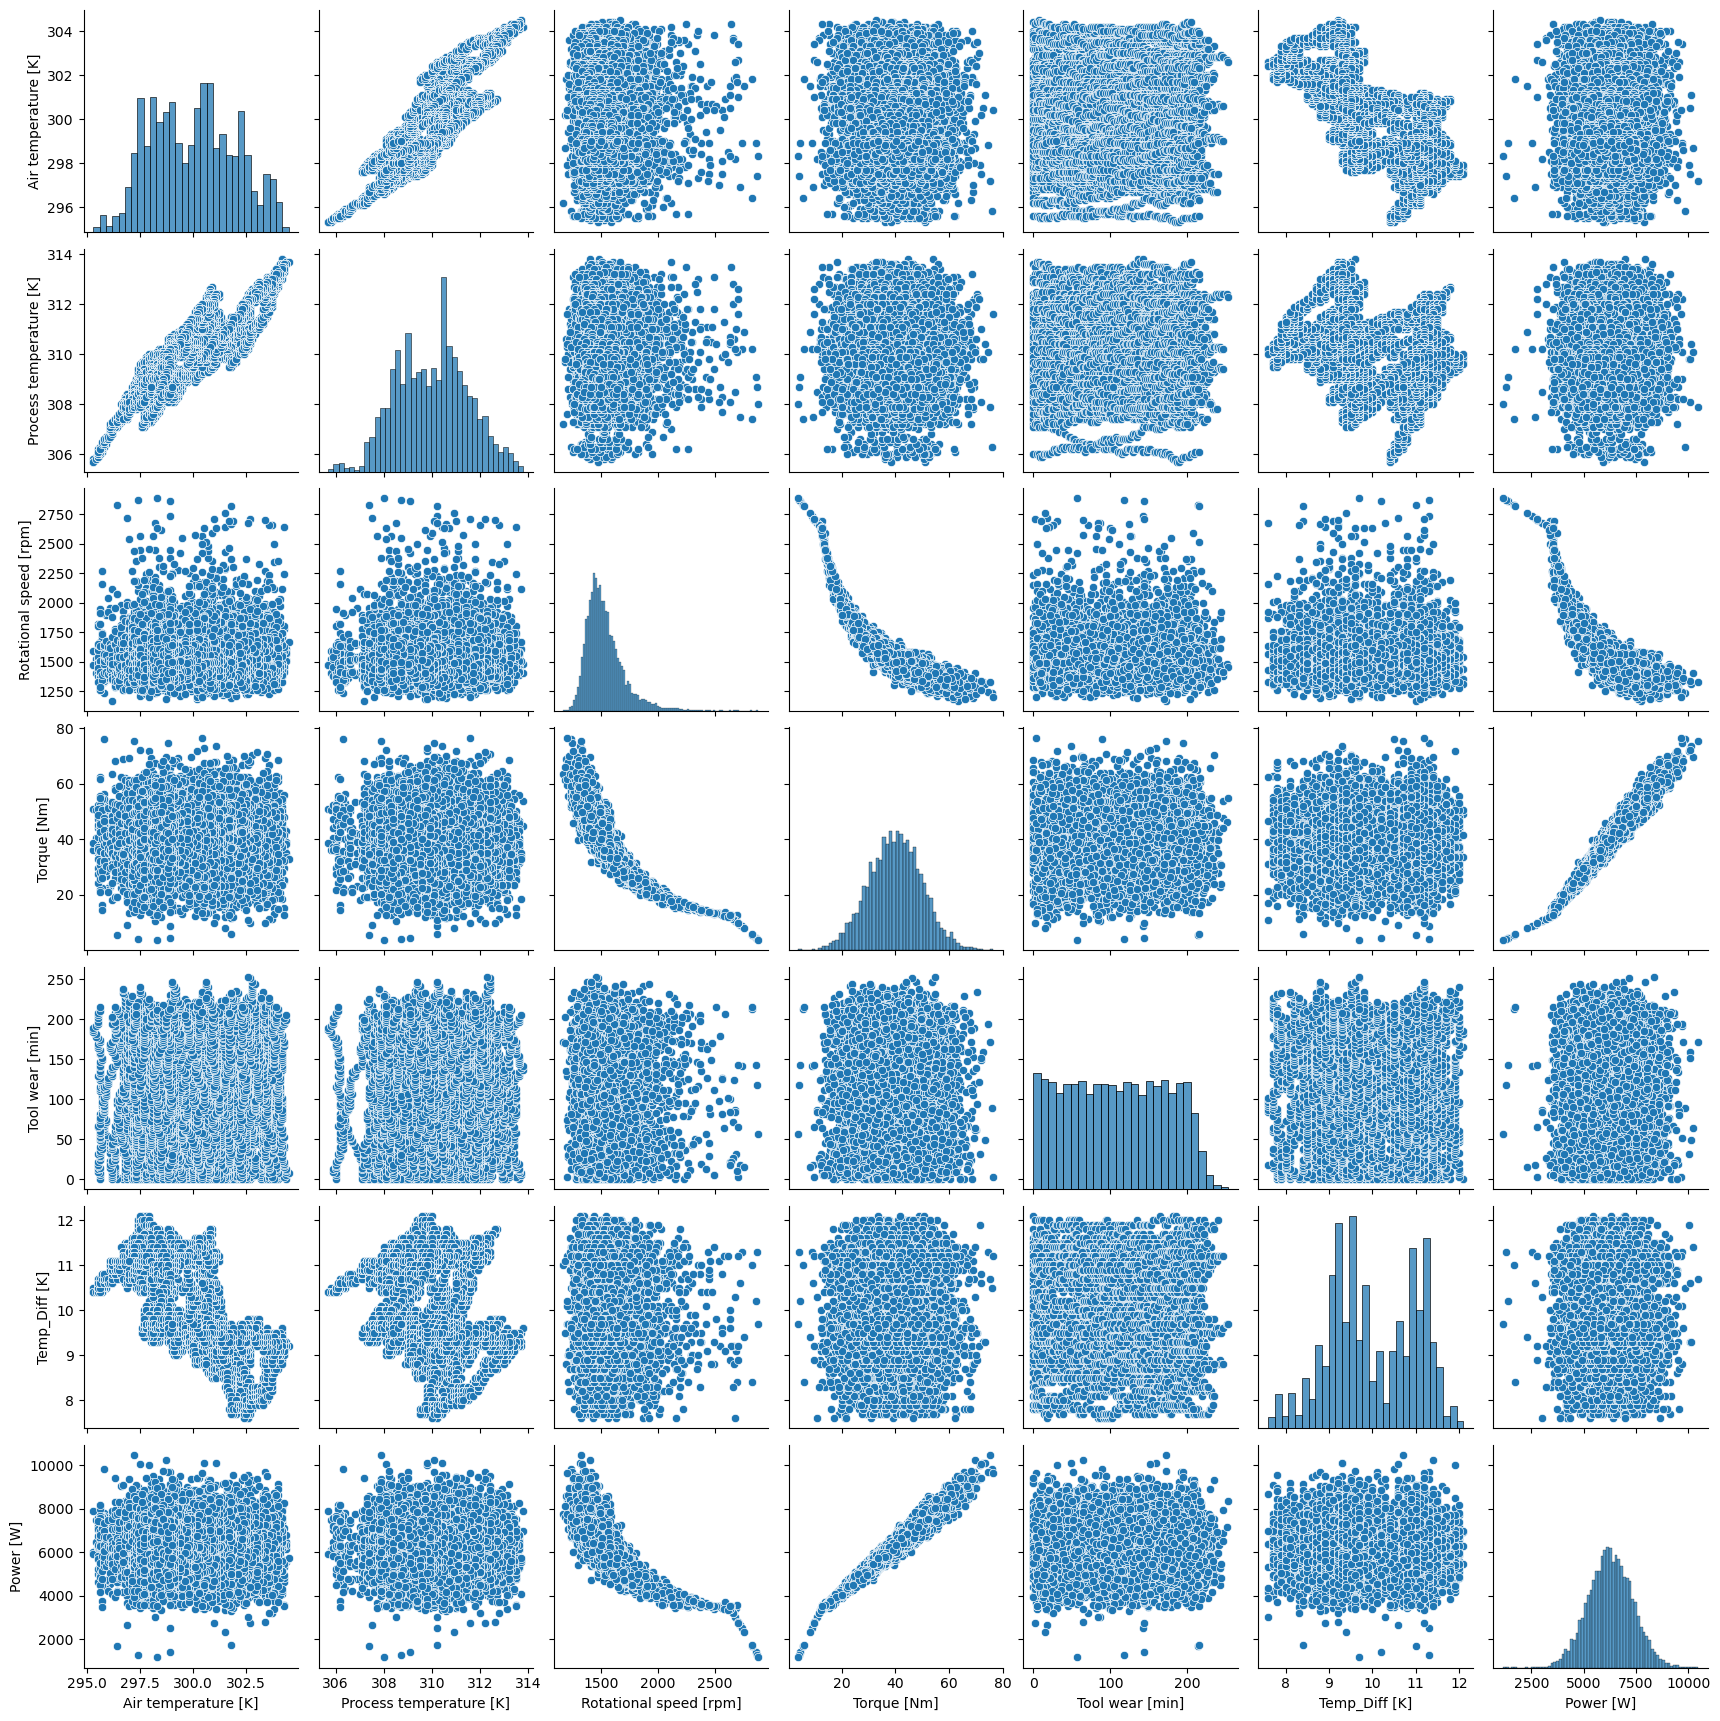

In [86]:
sns_plot = sns.pairplot(PDM_data_drop.select_dtypes(include='number'))

- **Positive correlation:** Between Air Temperature and Process Temperature.
- **Inverse correlation:** Between Rotational Speed and Torque.
- **Weak correlation:** With Tool Wear compared to other variables.
- **Complex patterns:** With Temp_Diff, suggesting nonlinear relationships that require further analysis.

The heatmap is suggested to quantify the strength and direction of relationships between variables, identify strong or weak correlations, and reduce redundant variables before modeling, especially in datasets with many variables.

Text(0.5, 1.0, 'Correlation heatmap')

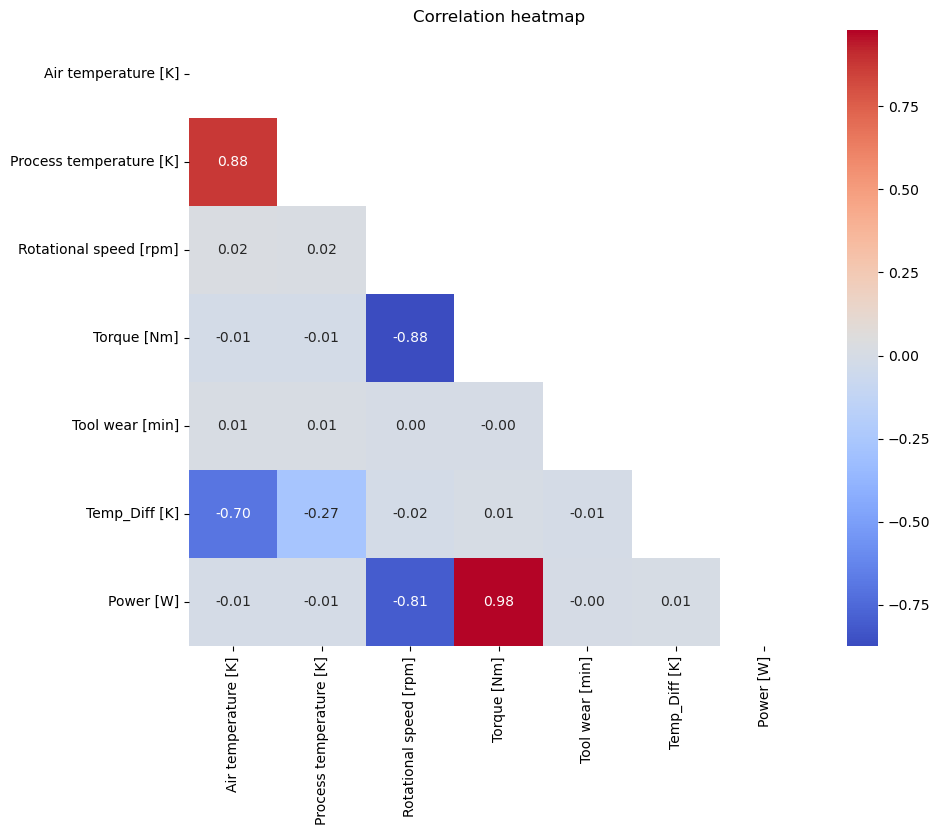

In [87]:
numeric_data = PDM_data.drop(columns=["Target", "UDI"]).select_dtypes(include='number')
calc = numeric_data.corr()
mask = np.triu(np.ones_like(calc, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax, mask=mask)
plt.title("Correlation heatmap")

- **Key Relationships:**  
   - Strong negative correlation between rotational speed and torque (-0.88).    
   - Weak negative correlation between process temperature and temperature difference (-0.27).  
   - Strong negative correlation between air temperature and temperature difference (-0.70).

- **Critical Insights:**  
   - As process temperature increases, rotational speed tends to increase.  
   - No correlation between process temperature and rotation speed or Torque
   - Temperature difference is more pronounced at lower air temperatures.  
   - A higher process temperature is linked to a lower temperature difference.



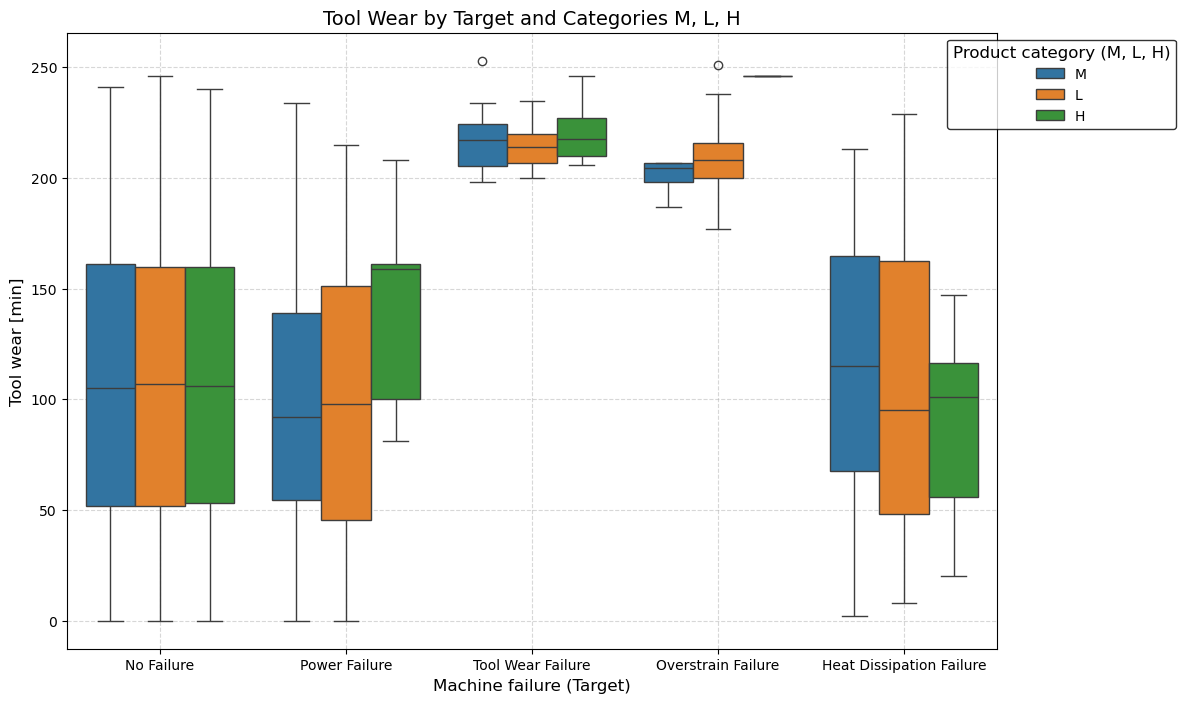

In [88]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.boxplot(data=PDM_data, x='Failure Type', y='Tool wear [min]', hue='Type', ax=ax)
plt.title('Tool Wear by Target and Categories M, L, H', fontsize=14)
plt.xlabel('Machine failure (Target)', fontsize=12)
plt.ylabel('Tool wear [min]', fontsize=12)
legend = ax.legend(title='Product category (M, L, H)', fontsize=10, title_fontsize=12, loc='upper right', bbox_to_anchor=(1.2, 1))
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('black')
ax.grid(True, linestyle='--', alpha=0.5)

**Tool Wear Failure:**  
The three categories (L, M, H) show similar median values and variability, with tool wear times consistently high. There is no significant difference between the product categories for this type of failure, and no clear indication that lower-quality products (L) have lower tool wear compared to higher-quality products (H).

**Power Failure and Overstrain Failure:**
Categories L and H show higher median values and greater variability compared to M. This indicates a broader range of tool wear times associated with these failure types, while M remains more stable and consistent.

**Random Failures:** 
Category H has a very low median and high variability, indicating failures occur at low tool wear times with inconsistent distribution. In contrast, M has a higher median and lower variability, while L shows intermediate behavior with moderate variability.

**Heat Dissipation Failure:**  
Category H also exhibits a low median and high variability, showing a tendency for failures to occur early with an irregular pattern. Categories M and L have higher medians and more stable distributions.

Overall, categories L and H show more variability across failure types, with H being particularly prone to lower median values and inconsistent distributions in random and heat dissipation failures. M remains more stable across all failure types.

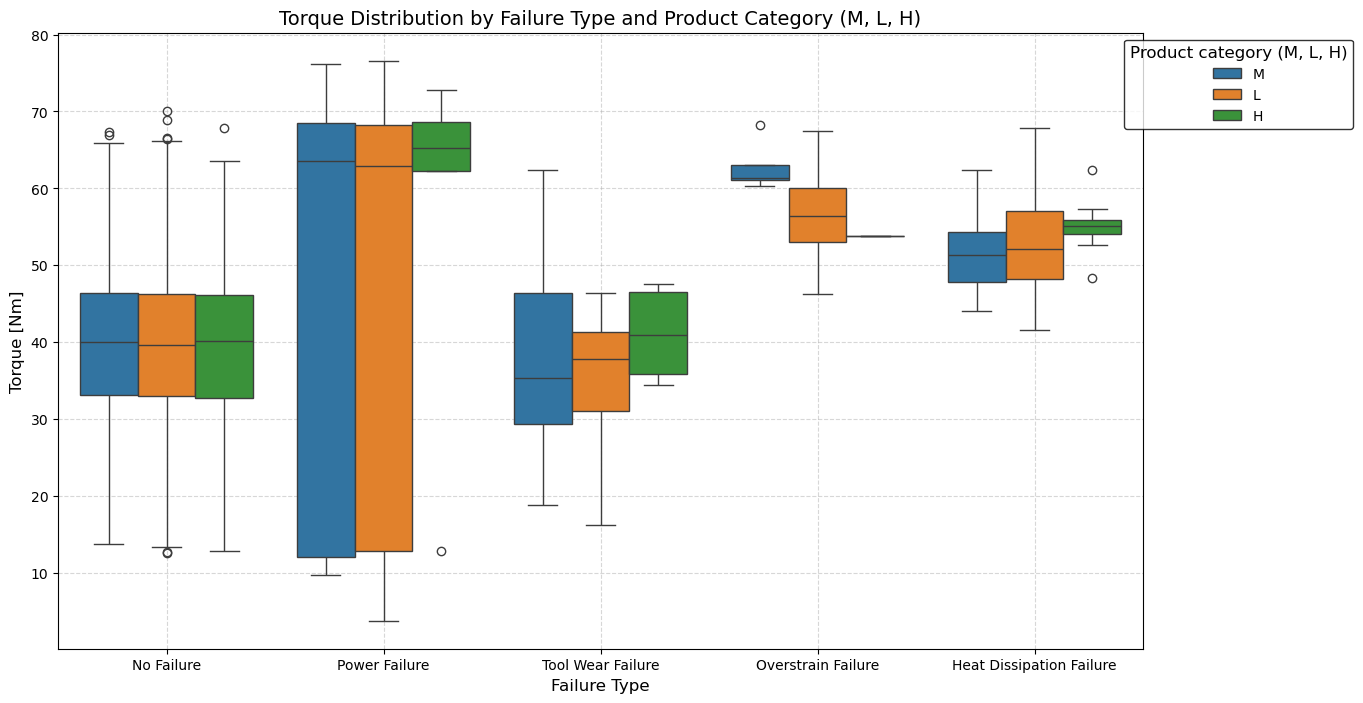

In [89]:
fig, ax = plt.subplots(figsize=(14, 8))
sns.boxplot(data=PDM_data, x='Failure Type', y='Torque [Nm]', hue='Type', ax=ax)
plt.title('Torque Distribution by Failure Type and Product Category (M, L, H)', fontsize=14)
plt.xlabel('Failure Type', fontsize=12)
plt.ylabel('Torque [Nm]', fontsize=12)
legend = ax.legend(title='Product category (M, L, H)', fontsize=10, title_fontsize=12, loc='upper right', bbox_to_anchor=(1.2, 1))
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('black')
ax.grid(True, linestyle='--', alpha=0.5)

- **No Failure:**  
   - The medians for the three categories (**M, L, H**) are close, around **40 Nm**.  
   - Significant variability is observed, with a range extending from **12 Nm to 65 Nm**.  
   - No notable differences between the categories are apparent.  

- **Power Failure:**  
   - The medians for the three categories show **extreme variability**, with a distribution ranging from **5 Nm to 75 Nm**.  
   - Categories **M (Medium)** and **L (Low)** exhibit particularly high dispersion, indicating instability in torque during these failures.  
   - This variability suggests a non-linear relationship between torque and other failure parameters.  

- **Tool Wear Failure:**  
   - Slight differences in medians.
   - Moderate variability is observed.  
   - Higher-quality products (**H**) show slightly higher torque at the point of failure.  

- **Overstrain Failure:**  
   - Elevated medians.
   - Variability is relatively low, indicating more predictable torque behavior in this failure type.  
   - Categories **M** and **L** show slightly higher medians compared to **H**.  

- **Random Failures:**  
   - Dispersed medians.
   - Significant variability is observed, especially in the **H** category, ranging from **20 Nm to 60 Nm**.  
   - No clear pattern emerges, consistent with the random nature of this failure type.  

- **Heat Dissipation Failure:**  
   - Relatively close medians.
   - A slight difference is noticeable, with a slightly higher median for the **H** category.  
   - Variability remains moderate and consistent across categories.  

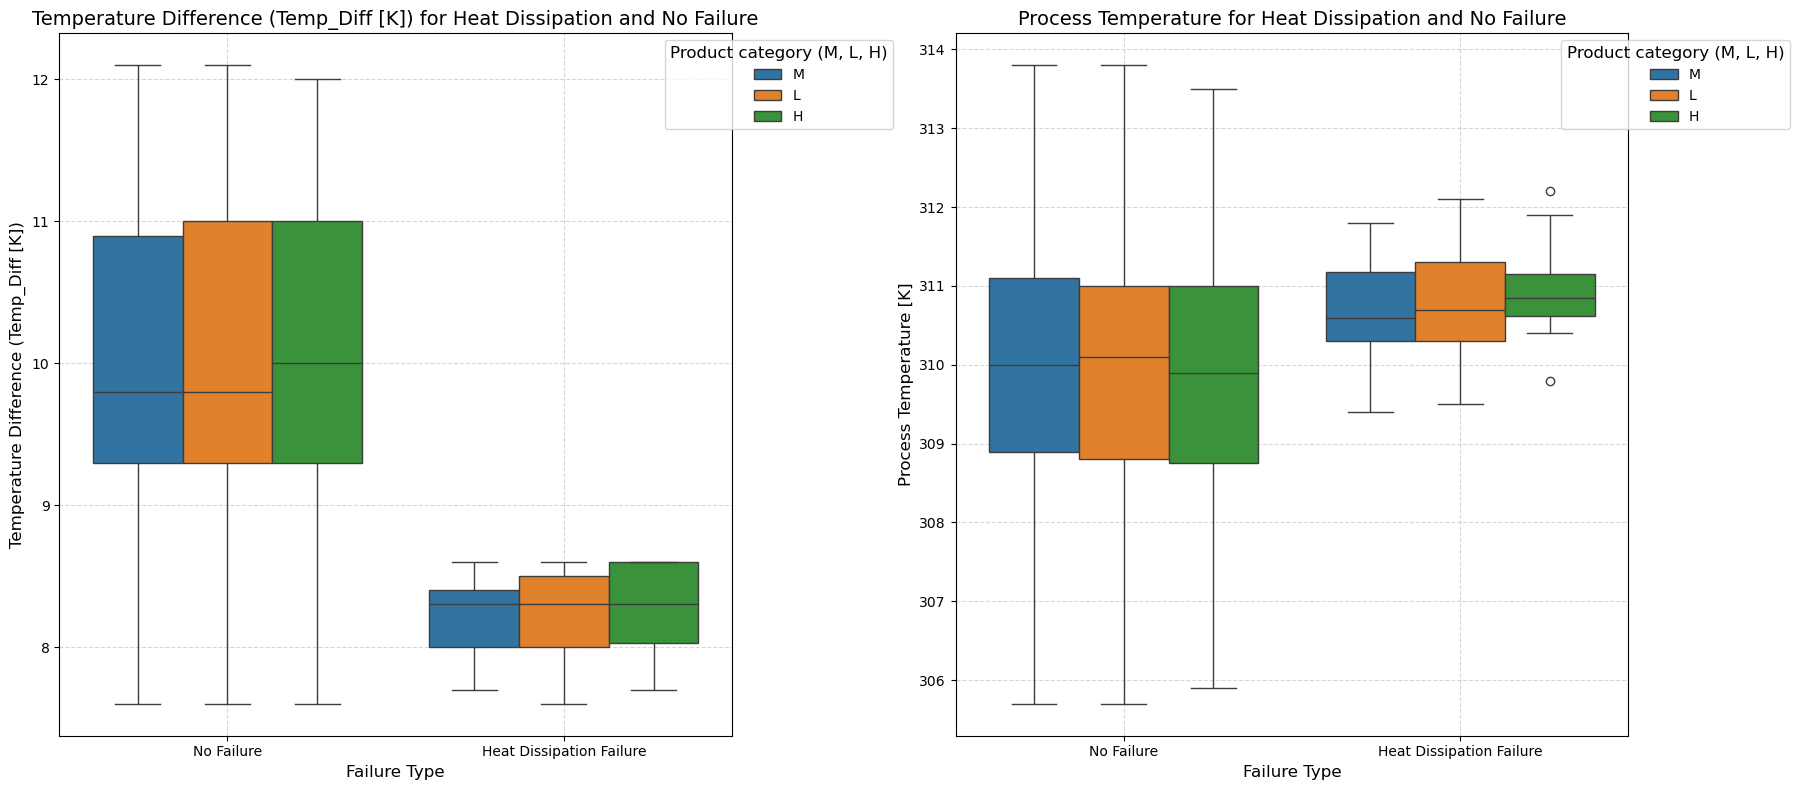

In [90]:
selected_failures = PDM_data[PDM_data['Failure Type'].isin(['Heat Dissipation Failure', 'No Failure'])]
palette = {'M': '#1f77b4', 'L': '#ff7f0e', 'H': '#2ca02c'}
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Boxplot for Temp_Diff
sns.boxplot(
    data=selected_failures,
    x='Failure Type',
    y='Temp_Diff [K]',
    hue='Type',  
    ax=axes[0],
    palette=palette
)
axes[0].set_title('Temperature Difference (Temp_Diff [K]) for Heat Dissipation and No Failure', fontsize=14)
axes[0].set_xlabel('Failure Type', fontsize=12)
axes[0].set_ylabel('Temperature Difference (Temp_Diff [K])', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(title='Product category (M, L, H)', fontsize=10, title_fontsize=12, loc='upper right', bbox_to_anchor=(1.25, 1))

# Boxplot for Process Temperature
sns.boxplot(
    data=selected_failures,
    x='Failure Type',
    y='Process temperature [K]',
    hue='Type',  
    ax=axes[1],
    palette=palette
)
axes[1].set_title('Process Temperature for Heat Dissipation and No Failure', fontsize=14)
axes[1].set_xlabel('Failure Type', fontsize=12)
axes[1].set_ylabel('Process Temperature [K]', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(title='Product category (M, L, H)', fontsize=10, title_fontsize=12, loc='upper right', bbox_to_anchor=(1.25, 1))

plt.tight_layout()
plt.show()

- **Temp_Diff shows a significant variation:** During a thermal failure, the median drops sharply (~8 K) with low variability, unlike the "No Failure" state where it is higher (~10 K) and more dispersed.  

- **Process Temperature remains stable:** The median stays constant around **310–311 K**, even during thermal failure, with a slight reduction in variability.  

- **Temp_Diff is more sensitive to thermal failures:** Its sharp decrease and low dispersion clearly indicate a loss of thermal efficiency in the system.  

- **Process Temperature is less discriminative:** It provides a more global overview and does not show a clear signal indicating an imminent thermal failure.  

- **The three categories (M, L, H) behave similarly:** No significant differences are observed across categories in either **Temp_Diff** or **Process Temperature** during thermal failures.  

- **Conclusion:** **Temp_Diff** is a more reliable and reactive indicator for detecting thermal failures, while **Process Temperature** remains useful for monitoring the overall thermal stability of the system.  


Text(0.5, 1.0, 'Relationship between Rotational Speed, Torque and Tool Wear with Target')

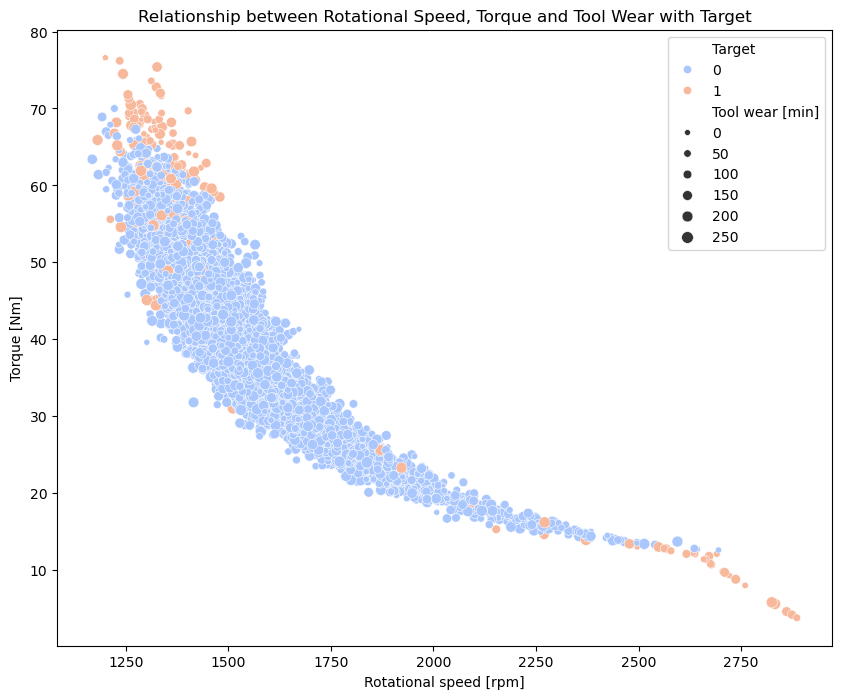

In [91]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=PDM_data, x='Rotational speed [rpm]', y='Torque [Nm]', hue='Target', size='Tool wear [min]', palette='coolwarm', ax=ax)
plt.title('Relationship between Rotational Speed, Torque and Tool Wear with Target')

- **Relationship between Rotational Speed and Torque:**
   - A clear inverse relationship is observed between rotational speed (rpm) and torque (Nm).  
   - At low speeds (<1500 rpm), torque is high (>50 Nm).  
   - At high speeds (>2000 rpm), torque is low (<20 Nm).  

- **Distribution of Targets (Target 0 and 1):**
   - Blue points (Target 0) represent operations without failure. They cover a wide range of speeds and torques.  
   - Orange points (Target 1) represent failures. They are mostly concentrated in the region of low speed (<1400 rpm) and high torque (>50 Nm).  
   - Few failures are observed at high speeds and low torques.  

- **Tool Wear:**  
   - The size of the points represents tool wear time (Tool Wear [min]).  
   - Higher tool wear is generally associated with lower speeds and higher torques.  
   - At higher speeds, tool wear remains low, even in failure cases (orange points).  

- **Critical Zone Identified:**
   - Failures are concentrated in a specific range:  
      - Rotational speed <1400 rpm  
      - Torque >50 Nm  
      - Moderate to high tool wear (>150 min)  

- **General Conclusion:**  
   - Failures are strongly correlated with low speeds and high torques.  
   - Tool wear also plays a role, with failures increasing as tool wear increases.  
   - At higher speeds, the risk of failure decreases, even with significant tool wear.

In [92]:
filtered_data = PDM_data[PDM_data['Failure Type'] != 'No Failure']
plot = filtered_data.hvplot.hist(
    y='Torque [Nm]',        
    by='Failure Type',      
    stacked=True,           
    bins=30,               
    cmap='Category10',     
    title='Torque Distribution by Failure Type',
    legend='top',          
    responsive=True,       
    height=500,
    width=700
).opts(
    active_tools=['box_zoom', 'pan'], 
    toolbar='above'
)

plot


:NdOverlay   [Failure Type]
   :Histogram   [Torque [Nm]]   (Count)

- **Torque Distribution Analysis:**  
   - The histogram shows the distribution of **Torque [Nm]** across different failure types: heat dissipation, overstrain, power failure, random failures, and tool wear failure.  
   - Each failure type displays a distinct range of torque values, highlighting their unique operational characteristics.

- **Heat Dissipation Failure:**  
   - Concentrated in the range of **45–65 Nm**.  
   - The distribution is relatively narrow, indicating a consistent pattern for this type of failure.  
   - Suggests that heat dissipation failures are strongly linked to a moderate torque range.

- **Overstrain Failure:**  
   - Mostly distributed between **50–70 Nm**.  
   - Displays a broader range, indicating variability in torque levels leading to overstrain failures.  
   - Overlap with other failure types suggests shared operational conditions.

- **Power Failure:**  
   - Exhibits a **bimodal distribution** with two distinct peaks: one in the **5–20 Nm** range and another in the **55–75 Nm** range.  
   - This pattern suggests multiple mechanisms driving power failures, potentially related to both low and high torque conditions.

- **Random Failures:**  
   - Scattered mainly around **50–60 Nm**.  
   - Sparse representation makes it difficult to draw clear patterns.  
   - Aligns with the inherently unpredictable nature of random failures.

- **Tool Wear Failure:**  
   - Distributed mostly between **30–50 Nm**.  
   - Shows a stable and uniform distribution.  
   - Indicates that tool wear failures occur in moderately stressed operational zones.

- **Key Observations:**  
   - Heat dissipation and overstrain failures share similar torque ranges (**45–70 Nm**).  
   - Power failures display a unique bimodal pattern, indicating two distinct failure mechanisms.  
   - Random failures lack a consistent pattern, confirming their stochastic nature.  
   - Tool wear failures are stable and occur predominantly in the **30–50 Nm** range.

- **Conclusion:**  
   - Torque values are a significant indicator for predicting failure types.  
   - Power failures stand out with their bimodal distribution, suggesting diverse root causes.  
   - Heat dissipation and overstrain failures show strong overlaps, suggesting shared contributing factors.  
   - Tool wear failures are more stable and occur within a predictable torque range.

In [93]:
filtered_data = PDM_data[PDM_data['Failure Type'] != 'No Failure']
plot = filtered_data.hvplot.hist(
    y='Rotational speed [rpm]',        
    by='Failure Type',      
    stacked=True,           
    bins=30,               
    cmap='Category10',     
    title='Rotational speed [rpm] by failure type',
    legend='top',          
    responsive=True,       
    height=500,
    width=700
).opts(
    active_tools=['box_zoom', 'pan'], 
    toolbar='above'
)
plot


:NdOverlay   [Failure Type]
   :Histogram   [Rotational speed [rpm]]   (Count)

- **Conclusion:**  
   - Thermal and overstrain failures are primarily concentrated in the **<1400 rpm** range.  
   - Power failures exhibit an **interesting bimodal distribution**, which warrants further analysis.  
   - Tool wear failures are mostly observed between **1200–1600 rpm**.  
   - This graph is relevant as it refines the understanding of critical speed ranges associated with each type of failure and complements previous analyses with an exclusive focus on rotational speed.


Text(0.5, 1.0, 'Relation entre Vitesse de Rotation et Torque par Type de Panne')

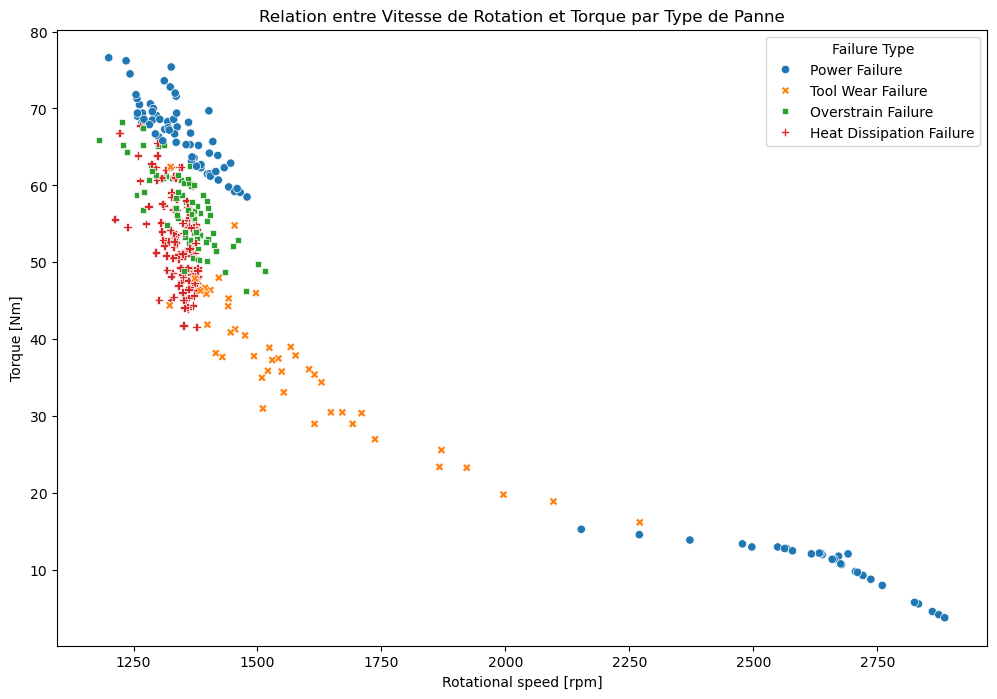

In [94]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=filtered_data, x='Rotational speed [rpm]', y='Torque [Nm]', hue='Failure Type', style='Failure Type')
plt.title('Relation entre Vitesse de Rotation et Torque par Type de Panne')

**Relationship Between Rotational Speed and Torque**
- Inverse correlation: Torque decreases as speed increases.
- Low speed (<1400 rpm) → High torque (>50 Nm)
- High speed (>2000 rpm) → Low torque (<20 Nm)

**Failure Type Distribution**
- Power failures: Appear at speed extremes (low/high).
- Tool wear failures: Occur at moderate speeds (1400–2000 rpm) with decreasing torque.
- Overstrain failures: Cluster at moderate speeds (1300–1500 rpm) with high torque (40–60 Nm).
- Random failures: Scattered around intermediate speeds and torques.
- Heat dissipation failures: Concentrate at low speeds (<1400 rpm) and high torque (>50 Nm).

**Critical Zones**
- Low speed & high torque: Heat dissipation and overstrain issues.
- Moderate speed & torque: Tool wear problems.
- High speed & low torque: Power failures.

**Key Observations**
- Failures cluster in distinct speed-torque zones.
- Each failure type aligns with a specific operational range.

**Added Value of the Graph**
- Segments failures visually by operational zone.
- Reveals clear patterns for predictive maintenance.

**Conclusion**
- Mapping failures to speed-torque ranges enables targeted monitoring.
- Provides a solid foundation for tailored predictive maintenance strategies.


# 5.0 Feature Engineering

In [95]:
%pip install -q scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [96]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [97]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    classification_report, confusion_matrix, roc_auc_score,  
)
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [98]:
# 📝 Étape 1 : Filtrer les lignes sans "Random Failure"
PDM_data = PDM_data[PDM_data['Failure Type', 'Product ID', 'UDI', "Type"] != 'Random Failure']

# 📝 Étape 2 : Extraction de lettres et chiffres du "Product ID"
PDM_data["Product_Letter"] = PDM_data["Product ID"].str[0]
PDM_data["Product_Number"] = PDM_data["Product ID"].str[1:].astype(int)

# 📝 Étape 3 : Encodage Manuel de Product_Letter
letter_mapping = {'H': 0, 'L': 1, 'M': 2}
PDM_data['Product_Letter_encoded'] = PDM_data['Product_Letter'].map(letter_mapping)

# 📝 Étape 4 : Reconstruction de Product_ID
PDM_data['Product_ID'] = (
    PDM_data['Product_Letter_encoded'].astype(str).str.zfill(1) +  # Lettre encodée
    PDM_data['Product_Number'].astype(str).str.zfill(5)  # Chiffres formatés sur 5 caractères
).astype(int)

# 📝 Étape 5 : Suppression des Colonnes Intermédiaires et Non Nécessaires
PDM_data.drop(columns=['Product_Letter', 'Product_Number', 'Product_Letter_encoded', ], inplace=True)

# 📝 Étape 6 : Afficher le DataFrame Final
print("\n✅ Données finales après transformation :")
print(PDM_data.head(10))
print("\n✅ Colonnes finales :")
print(PDM_data.columns)

KeyError: ('Failure Type', 'Product ID', 'UDI', 'Type')

In [ ]:
# 📝 Étape 12 : Réduction de la dimensionnalité avec PCA
pca = PCA(n_components=0.95)  # Conserve 95% de la variance
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# ✅ Affichage des résultats du PCA
print("✅ Variance expliquée par PCA :", pca.explained_variance_ratio_)
print("✅ Forme après PCA (Train) :", X_train_pca.shape)
print("✅ Forme après PCA (Test) :", X_test_pca.shape)



In [ ]:
smote = SMOTE(sampling_strategy=0.7, random_state=42, k_neighbors=3)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_pca, y_train)

print("Distribution après SMOTE :", pd.Series(y_train_resampled).value_counts())

In [ ]:
print("✅ Aperçu des données d'entraînement PCA :")
print(pd.DataFrame(X_train_pca).head())

print("✅ Distribution des labels (Entraînement) :", np.unique(y_train_encoded, return_counts=True))
print("✅ Distribution des labels (Test) :", np.unique(y_test_encoded, return_counts=True))
